# Exploratory Data Analysis - Banking77 Intent Classification

This notebook performs a basic exploratory data analysis on the Banking77 intent classification dataset.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset

from intent_classification.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR


sns.set_theme(style='whitegrid')

## Original Banking77 Dataset

Explores the original Banking77 data. It does not inspect model behavior or compare features for model design. 

### Data Loading

In [2]:
raw = load_dataset('mteb/banking77')
train_raw = raw['train'].to_pandas()
test_raw = raw['test'].to_pandas()

print('Original Banking77 loading report:')
print(f'- Train rows   : {len(train_raw):,}')
print(f'- Test rows    : {len(test_raw):,}')
print(f'- Columns      : {train_raw.columns.tolist()}')
print(f'- Intent labels: {train_raw["label_text"].nunique()}')

train_raw.head()

Original Banking77 loading report:
- Train rows   : 9,993
- Test rows    : 3,076
- Columns      : ['text', 'label', 'label_text']
- Intent labels: 77


,text,label,label_text
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


### Schema and Quality Checks

In [3]:
full_raw = pd.concat([train_raw, test_raw], ignore_index=True)

missing = full_raw.isnull().sum()
print('Missing values:', missing.to_dict())
print(f'Exact duplicate texts: {full_raw["text"].duplicated().sum()}')

Missing values: {'text': 0, 'label': 0, 'label_text': 0}
Exact duplicate texts: 0


### Intent Distribution (77 intents)

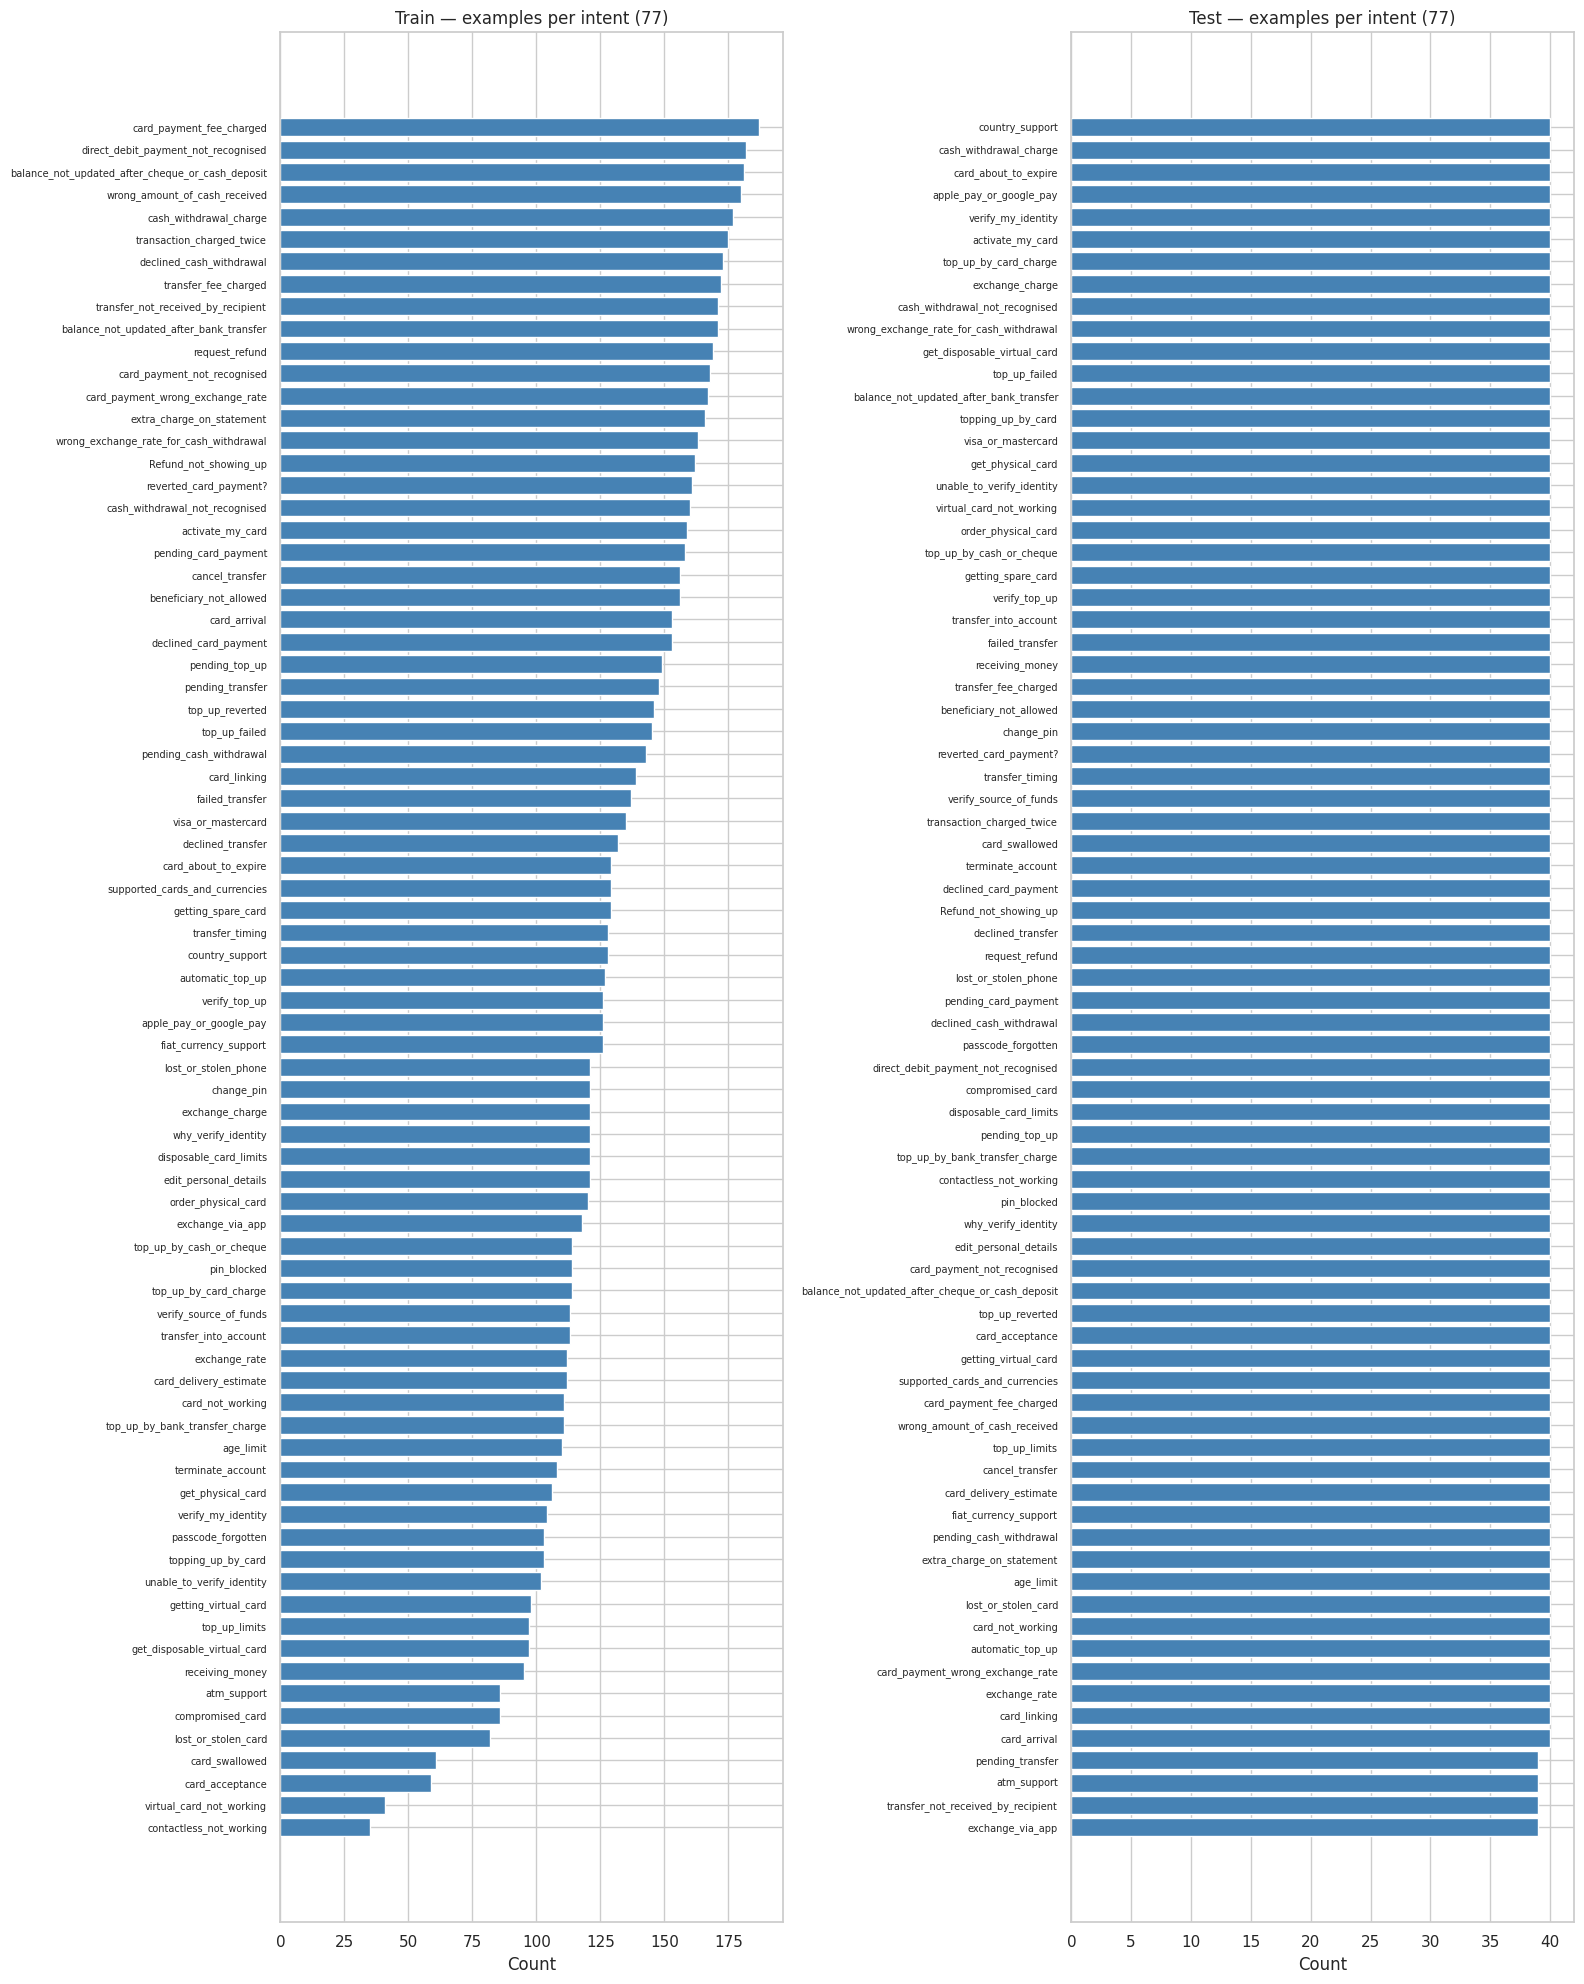

In [4]:
train_intent_counts = train_raw['label_text'].value_counts().sort_values()
test_intent_counts = test_raw['label_text'].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 20))
for ax, (counts, title) in zip(axes, [(train_intent_counts, 'Train'), (test_intent_counts, 'Test')]):
    ax.barh(counts.index, counts.values, color='steelblue')
    ax.set_xlabel('Count')
    ax.set_title(f'{title} — examples per intent (77)')
    ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

### Category Distribution (6 groups)

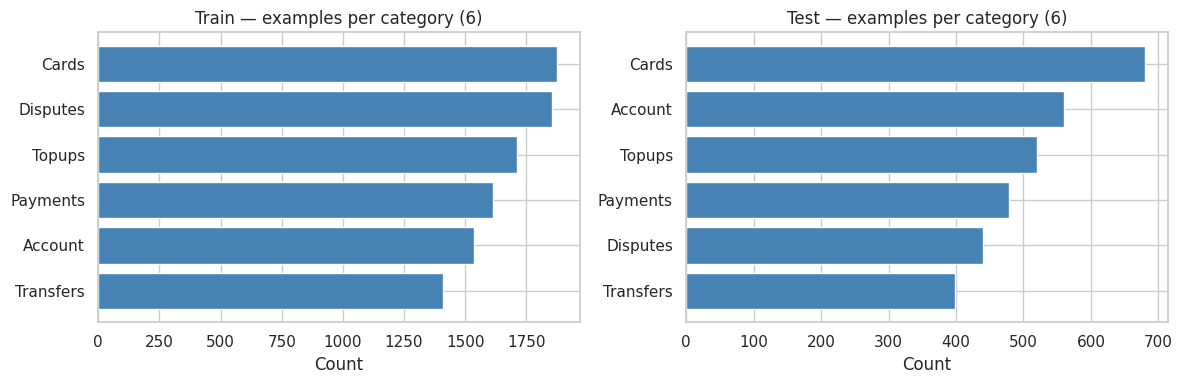

In [5]:
train_grouped = pd.read_csv(INTERIM_DATA_DIR / 'intents_train.csv')
test_grouped = pd.read_csv(INTERIM_DATA_DIR / 'intents_test.csv')

train_group_counts = train_grouped['label'].value_counts().sort_values()
test_group_counts = test_grouped['label'].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (counts, title) in zip(axes, [(train_group_counts, 'Train'), (test_group_counts, 'Test')]):
    ax.barh(counts.index, counts.values, color='steelblue')
    ax.set_xlabel('Count')
    ax.set_title(f'{title} — examples per category (6)')
plt.tight_layout()
plt.show()

## Train-Only Exploratory Analysis

Uses only the processed train split to describe class patterns and text features that can influence modeling decisions.

In [6]:
train_df = pd.read_csv(PROCESSED_DATA_DIR / 'train.csv')

print('Train split loading report:')
print(f'- Rows loaded: {len(train_df)}')
print(f'- Columns: {train_df.columns.tolist()}')

train_df.head()

Train split loading report:
- Rows loaded: 500
- Columns: ['text', 'label']


,text,label
0,There is a duplicate payment on my card. Why?,Disputes
1,I could not transfer to a beneficiary,Transfers
2,Whats the reason for my payment being declined...,Payments
3,What steps do I need to take to exchange curre...,Payments
4,Can you tell me about the exchange fee?,Payments


### Train Dataset Overview

In [7]:
print('Train dataset shape:', train_df.shape)
print('Unique intents:', train_df['label'].nunique())

train_df['label'].value_counts().sort_index()

Train dataset shape: (500, 2)
Unique intents: 6


label
Account      77
Cards        94
Disputes     93
Payments     81
Topups       85
Transfers    70
Name: count, dtype: int64

### Target Variable Analysis

#### Class distribution

,Count,Percentage
label,,
Transfers,70,14.0
Account,77,15.4
Payments,81,16.2
Topups,85,17.0
Disputes,93,18.6
Cards,94,18.8


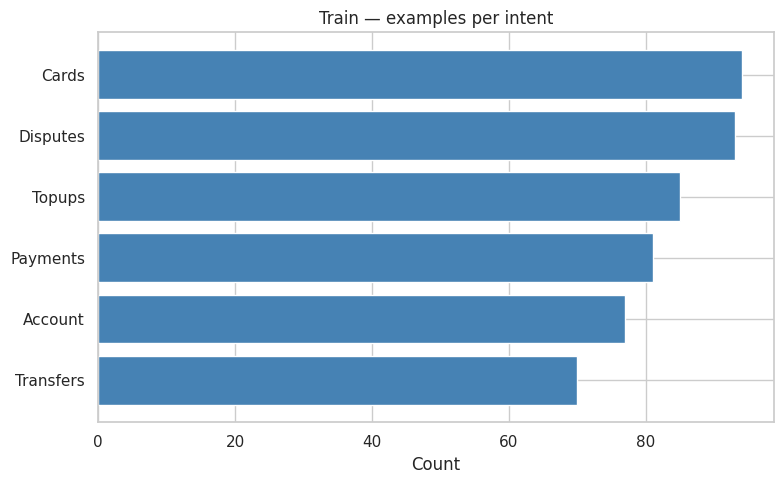

Min: 70, Max: 94, Mean: 83.3


In [8]:
counts = train_df['label'].value_counts().sort_values()
pct = train_df['label'].value_counts(normalize=True).sort_values() * 100

display(pd.DataFrame({'Count': counts, 'Percentage': pct}))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(counts.index, counts.values, color='steelblue')
ax.set_xlabel('Count')
ax.set_title('Train — examples per intent')
plt.tight_layout()
plt.show()

print(f'Min: {counts.min()}, Max: {counts.max()}, Mean: {counts.mean():.1f}')

### Feature Engineering

#### Text Features

In [9]:
train_df['text_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].str.split().str.len()

train_df[['text', 'text_length', 'word_count']].head()

,text,text_length,word_count
0,There is a duplicate payment on my card. Why?,45,9
1,I could not transfer to a beneficiary,37,7
2,Whats the reason for my payment being declined...,114,20
3,What steps do I need to take to exchange curre...,52,10
4,Can you tell me about the exchange fee?,39,8


#### Statistical Comparison by Class

In [10]:
stats_by_class = train_df.groupby('label')[['text_length', 'word_count']].agg(['mean', 'median', 'std'])
stats_by_class.round(2)

text_length               word_count             
                 mean median    std       mean median   std
label                                                      
Account         49.42   44.0  23.49      10.30    9.0  4.71
Cards           45.81   40.0  17.63       9.69    9.0  3.82
Disputes        76.04   56.0  49.09      14.83   11.0  9.68
Payments        62.73   51.0  42.19      12.64   10.0  8.78
Topups          59.96   48.0  39.45      12.32   10.0  7.70
Transfers       75.81   55.0  50.13      14.70   11.0  9.26

#### Visualizations

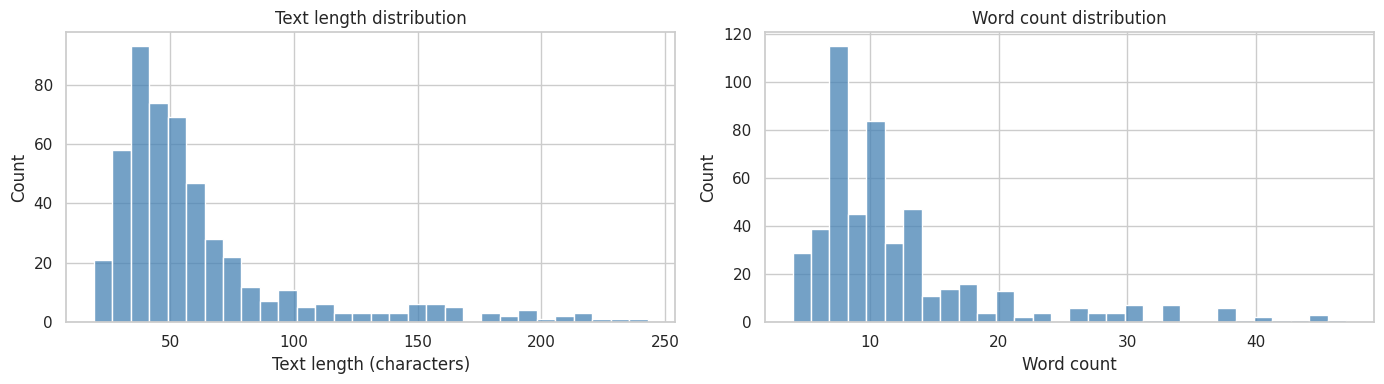

,count,mean,std,min,25%,50%,75%,max
text_length,500.0,61.336,40.234821,19.0,37.0,49.0,65.5,243.0
word_count,500.0,12.366,7.842132,4.0,8.0,10.0,13.0,47.0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(train_df['text_length'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Text length (characters)')
axes[0].set_ylabel('Count')
axes[0].set_title('Text length distribution')

sns.histplot(train_df['word_count'], bins=30, ax=axes[1], color='steelblue')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Count')
axes[1].set_title('Word count distribution')

plt.tight_layout()
plt.show()

train_df[['text_length', 'word_count']].describe().T

### Sample Queries per Intent

In [12]:
sample_intents = train_df['label'].drop_duplicates().sample(5, random_state=0).tolist()

for intent in sample_intents:
    print(f'--- {intent} ---')
    examples = train_df[train_df['label'] == intent]['text'].sample(3, random_state=0)
    for text in examples:
        print(f'  {text}')
    print()

--- Account ---
  How do I reset my passcode?
  There are a few transaction that I don't recognize, I think someone managed to get my card details and use it.

  How can I edit my personal details in the app?

--- Payments ---
  Hello, I tried to take some cash out of the ATM but I looked at my statement and it still shows that it's pending. Is the machine broken? Will I receive my money back or will I be charged for this?
  I have a payment which has not been approved.
  Why did I get charged extra?

--- Transfers ---
  Is there any way to cancel my transfer
  I just did a money transaction but its not showing they received it
  How long does transfer from the US take?

--- Topups ---
  Can I use google pay to top up?
  How do I top up on my card?
  I am unable to use my top-up on the app. Could you explain this to me?

--- Disputes ---
  Why is there an extra charge on my statement.
  There was money taken out of my account, and I'm pretty sure I didn't do it.
  I got some cash but i